# Oliver-Pharr Nanoindentation Analysis — Fe-Cr All Compositions

**Project:** Elastic Constants of Binary Alloys — DFT → ML Surrogate → FEM  
**Compositions:** Fe16Cr0, Fe8Cr8, Fe4Cr12, Fe0Cr16  
**Source runs:** `indentation_fe*_v19` (CalculiX CCX 2.21, conical indenter, CAX6 axisymmetric)  
**Units throughout:** µm / µN / MPa

This notebook processes all four composition `.dat` files in a single pass.  
**Missing `.dat` files are silently skipped** — the composition appears in the final
summary table and Er vs Cr% plot as a gap rather than raising an error.

Two corrections are applied to every composition — see Methodology Note.

## Methodology Note

### 1. Axisymmetric 2-degree wedge force scaling (×180)

CalculiX expands axisymmetric `CAX*` elements into a **fixed 2-degree wedge**.
The reaction force in the `.dat` file is for that sector, not the full 360°:

$$F_{\text{physical}} = F_{\text{reported}} \times \frac{360}{2} = F_{\text{reported}} \times 180$$

CCX 2.21 manual references: §6.2.30 (CAX8), §10.3.8 (concentrated forces), §7.118 (SOLID SECTION).  
Without this factor the modulus is ~180× too low.

### 2. Exclusion of zero-contact unloading points

At $K = 5\,C_{11}$ (lower-bound penalty stiffness) the surface can recover faster
than the indenter retracts. Once $P = 0$ the indenter has separated — these points
are free-space travel, not unloading mechanics, and are excluded from the O-P fit.
They are shown explicitly on each P-h plot.

### Oliver-Pharr relations used

$$P = A\,(h - h_f)^m \qquad S = Am(h_{max}-h_f)^{m-1}$$
$$h_c = h_{max} - \varepsilon\,P_{max}/S, \quad \varepsilon = 0.72\ (\text{conical})$$
$$A_c = \pi(h_c\tan\theta)^2,\quad \theta = 70.3°$$
$$E_r = \frac{\sqrt{\pi}}{2}\frac{S}{\sqrt{A_c}} \qquad
\frac{1}{E_{r,\text{sample}}} = \frac{1}{E_r} - \frac{1-\nu_i^2}{E_i}$$

Diamond indenter: $E_i = 1{,}141{,}000$ MPa, $\nu_i = 0.07$.

In [16]:
import re
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd

# ── physical / geometric constants (verified against inp files / CCX manual) ──
WEDGE_SCALE     = 180.0        # 360/2 — CCX axisymmetric 2-degree wedge correction
EPS             = 0.72         # Oliver-Pharr geometric constant, conical
THETA_DEG       = 70.3         # indenter half-included angle
E_INDENTER      = 1_141_000.0  # diamond, MPa
NU_INDENTER     = 0.07
FIT_FRACTION    = 0.50         # upper fraction of unloading curve used for O-P fit
CONTACT_FORCE_TOL = 1e-2       # uN; below this, contact is treated as lost

# ── composition registry ──────────────────────────────────────────────────────
# Keys must match the subdirectory names under fem/conical/
# E_R_ANALYTICAL: Hill-VRH values (GPa) derived from DFT/ML elastic constants
# C11_MPA: from calculix_material_cards_best.inp, used for K annotation only
COMPOSITIONS = [
    dict(tag="fe16cr00", label="Fe16Cr0", cr_pct=0,  E_R_ANALYTICAL=224.9),
    dict(tag="fe08cr08", label="Fe8Cr8",  cr_pct=50, E_R_ANALYTICAL=223.0),
    dict(tag="fe04cr12", label="Fe4Cr12", cr_pct=75, E_R_ANALYTICAL=257.3),
    dict(tag="fe00cr16", label="Fe0Cr16",  cr_pct=100,E_R_ANALYTICAL=256.6),
]


# ── path configuration ───────────────────────────────────────────────────────
FEM_CONICAL_DIR = Path("../fem/conical")    # parent of fe16cr00/, fe08cr08/, ...
POST_DIR        = Path("../fem/post")       # output directory for plots / csv
POST_DIR.mkdir(parents=True, exist_ok=True)

def dat_path(tag):
    return FEM_CONICAL_DIR / tag / f"indentation_{tag}_v19.dat"

print("Configuration loaded.")
print(f"Looking for .dat files in: {FEM_CONICAL_DIR.resolve()}")
for c in COMPOSITIONS:
    p = dat_path(c['tag'])
    status = "FOUND" if p.exists() else "MISSING"
    print(f"  {c['label']:10s}  {status:8s}  {p}")

Configuration loaded.
Looking for .dat files in: /home/sayeed/dft_projects/fe-cr_cu-ni_DFT/fem/conical
  Fe16Cr0     FOUND     ../fem/conical/fe16cr00/indentation_fe16cr00_v19.dat
  Fe8Cr8      FOUND     ../fem/conical/fe08cr08/indentation_fe08cr08_v19.dat
  Fe4Cr12     FOUND     ../fem/conical/fe04cr12/indentation_fe04cr12_v19.dat
  Fe0Cr16     FOUND     ../fem/conical/fe00cr16/indentation_fe00cr16_v19.dat


In [17]:
# ── parser ───────────────────────────────────────────────────────────────────
def parse_ccx_dat(fpath):
    """Parse a CalculiX .dat file with *NODE PRINT TOTALS output.

    Returns list of (step, increment, |U2|, |Fy|) tuples.
    U2 = prescribed axial displacement (indentation depth).
    Fy = axial reaction force on driven indenter node set.
    Forces are returned RAW (no wedge scaling applied yet).
    """
    content = Path(fpath).read_text()
    step_blocks = re.split(r"S T E P\s+(\d+)", content)
    records = []
    for s in range(1, len(step_blocks), 2):
        step_nr = int(step_blocks[s])
        inc_blocks = re.split(r"INCREMENT\s+(\d+)", step_blocks[s + 1])
        for i in range(1, len(inc_blocks), 2):
            inc_nr = int(inc_blocks[i])
            blk = inc_blocks[i + 1]
            tm = re.search(r"displacements.*?\n\s+\d+\s+[\d.E+\-]+\s+([\-\d.E+]+)", blk)
            fm = re.search(r"total force.*?\n\s+([\-\d.E+]+)\s+([\-\d.E+]+)\s+([\-\d.E+]+)", blk)
            if tm and fm:
                records.append((step_nr, inc_nr,
                                abs(float(tm.group(1))),
                                abs(float(fm.group(2)))))
    return records


# ── Oliver-Pharr fit ─────────────────────────────────────────────────────────
def oliver_pharr(h_ul, P_ul, h_max, P_max, fit_fraction=0.50):
    """Fit P = A (h - h_f)^m on the upper `fit_fraction` of the unloading curve.

    h_f is found by scanning for the best R² subject to 1 < m < 3.
    Returns a dict of fit parameters and derived O-P quantities.
    """
    best = None
    for hf in np.arange(0.001, h_max * 0.6, 0.001):
        shifted = h_ul - hf
        if np.any(shifted <= 0):
            continue
        mask = P_ul >= fit_fraction * P_max
        if mask.sum() < 5:
            continue
        try:
            c = np.polyfit(np.log(shifted[mask]), np.log(P_ul[mask]), 1)
            m, A = c[0], np.exp(c[1])
        except Exception:
            continue
        if not (1.0 < m < 3.0):
            continue
        pred  = A * (h_ul[mask] - hf) ** m
        ss_res = np.sum((P_ul[mask] - pred) ** 2)
        ss_tot = np.sum((P_ul[mask] - P_ul[mask].mean()) ** 2)
        r2 = 1 - ss_res / ss_tot
        if best is None or r2 > best["r2"]:
            best = dict(r2=r2, h_f=hf, m=m, A=A, n_fit=int(mask.sum()))
    if best is None:
        raise RuntimeError("No valid power-law fit found.")

    A, m, h_f = best["A"], best["m"], best["h_f"]
    S        = A * m * (h_max - h_f) ** (m - 1)
    h_c      = h_max - EPS * P_max / S
    A_c      = np.pi * (h_c * np.tan(np.radians(THETA_DEG))) ** 2
    Er       = S * np.sqrt(np.pi) / (2 * np.sqrt(A_c))
    Er_sample = 1.0 / (1.0 / Er - (1 - NU_INDENTER**2) / E_INDENTER)
    best.update(S=S, h_c=h_c, A_c=A_c, Er=Er, Er_sample=Er_sample)
    return best


print("Functions defined.")

Functions defined.


In [18]:
# ── main processing loop ─────────────────────────────────────────────────────
results = []   # one dict per composition (present or absent)

for comp in COMPOSITIONS:
    tag   = comp["tag"]
    label = comp["label"]
    er_ref = comp["E_R_ANALYTICAL"]
    fpath  = dat_path(tag)

    if not fpath.exists():
        print(f"[{label}] .dat not found — skipping.")
        results.append({"label": label, "cr_pct": comp["cr_pct"],
                        "status": "missing", "E_R_ANALYTICAL": er_ref})
        continue

    try:
        records  = parse_ccx_dat(fpath)
        n_steps  = max(r[0] for r in records)

        loading       = [(h, F*WEDGE_SCALE) for (st,inc,h,F) in records if st < n_steps]
        unloading_raw = [(inc, h, F*WEDGE_SCALE) for (st,inc,h,F) in records if st == n_steps]

        h_load = np.array([x[0] for x in loading])
        P_load = np.array([x[1] for x in loading])
        i_peak = int(np.argmax(h_load))
        h_max, P_max = h_load[i_peak], P_load[i_peak]

        unload_contact = [(h, P) for (_,h,P) in unloading_raw if P > CONTACT_FORCE_TOL]
        unload_lost    = [(h, P) for (_,h,P) in unloading_raw if P <= CONTACT_FORCE_TOL]

        h_ul = np.array([x[0] for x in unload_contact])
        P_ul = np.array([x[1] for x in unload_contact])
        order = np.argsort(h_ul)[::-1]
        h_ul, P_ul = h_ul[order], P_ul[order]
        h_excluded = np.array([x[0] for x in unload_lost])

        fit = oliver_pharr(h_ul, P_ul, h_max, P_max, FIT_FRACTION)
        Er_GPa = fit["Er_sample"] / 1000
        dev    = (Er_GPa - er_ref) / er_ref * 100

        results.append({
            "label": label, "cr_pct": comp["cr_pct"], "status": "ok",
            "E_R_ANALYTICAL": er_ref,
            "h_max": h_max, "P_max": P_max,
            "h_f": fit["h_f"], "m": fit["m"], "r2": fit["r2"],
            "S": fit["S"], "h_c": fit["h_c"], "A_c": fit["A_c"],
            "Er_measured_GPa": fit["Er"] / 1000,
            "Er_corrected_GPa": Er_GPa,
            "deviation_pct": dev,
            "n_excluded": len(unload_lost),
            # store arrays for the plot panel
            "_h_load": h_load, "_P_load": P_load,
            "_h_ul": h_ul, "_P_ul": P_ul,
            "_h_excluded": h_excluded, "_fit": fit,
        })
        print(f"[{label}]  h_max={h_max:.4f} µm  "
              f"Er_sample={Er_GPa:.1f} GPa  (ref {er_ref:.1f} GPa)  "
              f"dev={dev:+.1f}%  R²={fit['r2']:.5f}")

    except Exception as exc:
        print(f"[{label}] ERROR: {exc}")
        results.append({"label": label, "cr_pct": comp["cr_pct"],
                        "status": "error", "error": str(exc),
                        "E_R_ANALYTICAL": er_ref})

[Fe16Cr0]  h_max=0.4040 µm  Er_sample=196.9 GPa  (ref 224.9 GPa)  dev=-12.4%  R²=0.99996
[Fe8Cr8]  h_max=0.4040 µm  Er_sample=220.5 GPa  (ref 223.0 GPa)  dev=-1.1%  R²=0.99773
[Fe4Cr12]  h_max=0.4040 µm  Er_sample=247.7 GPa  (ref 257.3 GPa)  dev=-3.7%  R²=0.99965
[Fe0Cr16]  h_max=0.4040 µm  Er_sample=274.0 GPa  (ref 256.6 GPa)  dev=+6.8%  R²=0.99985


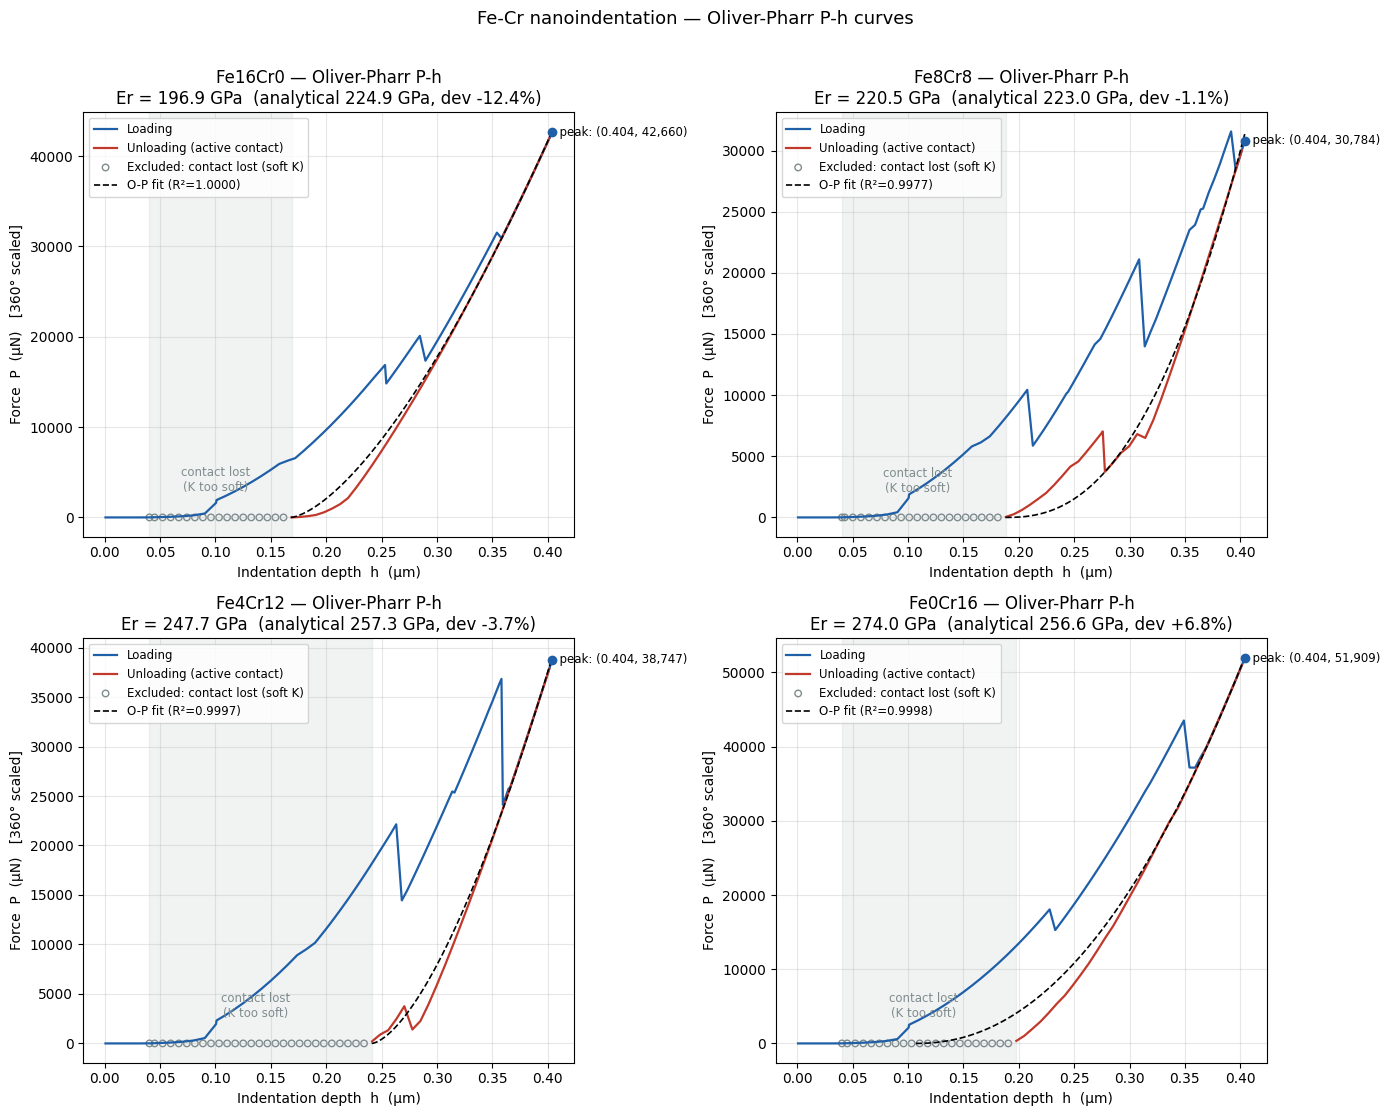

Panel plot saved to ../fem/post/fecr_all_oliver_pharr_ph.png


In [19]:
# ── P-h plots, one panel per available composition ────────────────────────────
ok_results = [r for r in results if r.get("status") == "ok"]
n_ok = len(ok_results)

if n_ok == 0:
    print("No completed runs available yet — P-h plots skipped.")
else:
    ncols = min(n_ok, 2)
    nrows = (n_ok + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(7*ncols, 5.5*nrows), squeeze=False)

    for idx, r in enumerate(ok_results):
        ax  = axes[idx // ncols][idx % ncols]
        fit = r["_fit"]
        h_load, P_load       = r["_h_load"], r["_P_load"]
        h_ul, P_ul           = r["_h_ul"],   r["_P_ul"]
        h_excluded           = r["_h_excluded"]
        h_max, P_max         = r["h_max"],    r["P_max"]

        ax.plot(h_load, P_load, "-", color="#1f5fa8", lw=1.6, label="Loading")
        ax.plot(h_ul,   P_ul,   "-", color="#c0392b", lw=1.6,
                label="Unloading (active contact)")

        if len(h_excluded):
            ax.scatter(h_excluded, np.zeros_like(h_excluded), s=22,
                       facecolor="none", edgecolor="#7f8c8d",
                       label="Excluded: contact lost (soft K)")
            ax.axvspan(h_excluded.min(), h_ul.min(), color="#7f8c8d", alpha=0.10)
            ax.text(h_excluded.mean(), 0.06 * P_max,
                    "contact lost\n(K too soft)", ha="center", va="bottom",
                    fontsize=8.5, color="#7f8c8d")

        h_dense = np.linspace(fit["h_f"] + 1e-4, h_max, 200)
        P_dense = fit["A"] * (h_dense - fit["h_f"]) ** fit["m"]
        ax.plot(h_dense, P_dense, "--", color="black", lw=1.2,
                label=f"O-P fit (R²={fit['r2']:.4f})")

        ax.scatter([h_max], [P_max], color="#1f5fa8", zorder=5)
        ax.annotate(f"  peak: ({h_max:.3f}, {P_max:,.0f})",
                    (h_max, P_max), fontsize=8.5, va="center")

        ax.set_xlabel("Indentation depth  h  (µm)")
        ax.set_ylabel("Force  P  (µN)   [360° scaled]")
        ax.set_title(
            f"{r['label']} — Oliver-Pharr P-h\n"
            f"Er = {r['Er_corrected_GPa']:.1f} GPa  "
            f"(analytical {r['E_R_ANALYTICAL']:.1f} GPa, "
            f"dev {r['deviation_pct']:+.1f}%)"
        )
        ax.legend(loc="upper left", fontsize=8.5)
        ax.grid(alpha=0.3)

        # save individual plot as well
        fig_single, ax_s = plt.subplots(figsize=(8, 6))
        ax_s.plot(h_load, P_load, "-", color="#1f5fa8", lw=1.6, label="Loading")
        ax_s.plot(h_ul, P_ul, "-", color="#c0392b", lw=1.6,
                  label="Unloading (active contact)")
        if len(h_excluded):
            ax_s.scatter(h_excluded, np.zeros_like(h_excluded), s=22,
                         facecolor="none", edgecolor="#7f8c8d",
                         label="Excluded: contact lost")
            ax_s.axvspan(h_excluded.min(), h_ul.min(), color="#7f8c8d", alpha=0.10)
        ax_s.plot(h_dense, P_dense, "--", color="black", lw=1.2,
                  label=f"O-P fit (R²={fit['r2']:.4f})")
        ax_s.scatter([h_max], [P_max], color="#1f5fa8", zorder=5)
        ax_s.annotate(f"  peak: ({h_max:.3f}, {P_max:,.0f})",
                      (h_max, P_max), fontsize=9, va="center")
        ax_s.set_xlabel("Indentation depth  h  (µm)")
        ax_s.set_ylabel("Force  P  (µN)   [360° scaled]")
        ax_s.set_title(
            f"{r['label']} — Oliver-Pharr P-h\n"
            f"Er = {r['Er_corrected_GPa']:.1f} GPa  "
            f"(analytical {r['E_R_ANALYTICAL']:.1f} GPa)"
        )
        ax_s.legend(loc="upper left", fontsize=9)
        ax_s.grid(alpha=0.3)
        fig_single.tight_layout()
        fname = POST_DIR / f"fecr_{r['label'].lower().replace(' ','')}_oliver_pharr.png"
        fig_single.savefig(fname, dpi=150, bbox_inches="tight")
        plt.close(fig_single)

    # hide unused subplots
    for idx in range(n_ok, nrows * ncols):
        axes[idx // ncols][idx % ncols].set_visible(False)

    fig.suptitle("Fe-Cr nanoindentation — Oliver-Pharr P-h curves", fontsize=13, y=1.01)
    fig.tight_layout()
    fig.savefig(POST_DIR / "fecr_all_oliver_pharr_ph.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Panel plot saved to {POST_DIR / 'fecr_all_oliver_pharr_ph.png'}")

In [20]:
# ── per-composition summary table ─────────────────────────────────────────────
rows = []
for r in results:
    if r.get("status") == "ok":
        rows.append({
            "Composition":        r["label"],
            "Cr%":                r["cr_pct"],
            "h_max (µm)":         f"{r['h_max']:.4f}",
            "P_max (µN)": f"{r['P_max']:,.1f}",
            "h_f (µm)":           f"{r['h_f']:.4f}",
            "m":                  f"{r['m']:.4f}",
            "R²":                 f"{r['r2']:.5f}",
            "S (µN/µm)":  f"{r['S']:,.0f}",
            "h_c (µm)":           f"{r['h_c']:.4f}",
            "A_c (µm²)":          f"{r['A_c']:.4f}",
            "Er_meas (GPa)":      f"{r['Er_measured_GPa']:.1f}",
            "Er_corr (GPa)":      f"{r['Er_corrected_GPa']:.1f}",
            "Er_analytical (GPa)":f"{r['E_R_ANALYTICAL']:.1f}",
            "dev (%)": f"{r['deviation_pct']:+.1f}",
            "excl. pts":          r["n_excluded"],
        })
    else:
        rows.append({
            "Composition":        r["label"],
            "Cr%":                r["cr_pct"],
            "h_max (µm)":         "—",
            "P_max (µN)":         "—",
            "h_f (µm)":           "—",
            "m":                  "—",
            "R²":                 "—",
            "S (µN/µm)":          "—",
            "h_c (µm)":           "—",
            "A_c (µm²)":          "—",
            "Er_meas (GPa)":      "—",
            "Er_corr (GPa)":      "—",
            "Er_analytical (GPa)":f"{r['E_R_ANALYTICAL']:.1f}",
            "dev (%)": r.get("status", "—"),
            "excl. pts":          "—",
        })

df_summary = pd.DataFrame(rows)
df_summary.to_csv(POST_DIR / "fecr_all_oliver_pharr_summary.csv", index=False)
print(f"Summary CSV saved to {POST_DIR / 'fecr_all_oliver_pharr_summary.csv'}")
df_summary

Summary CSV saved to ../fem/post/fecr_all_oliver_pharr_summary.csv


,Composition,Cr%,h_max (µm),P_max (µN),h_f (µm),m,R²,S (µN/µm),h_c (µm),A_c (µm²),Er_meas (GPa),Er_corr (GPa),Er_analytical (GPa),dev (%),excl. pts
0,Fe16Cr0,0,0.4040,"42,659.6",0.1680,1.5131,0.99996,"274,013",0.2919,2.0881,168.1,196.9,224.9,-12.4,18
1,Fe8Cr8,50,0.4040,"30,783.9",0.1880,2.4280,0.99773,"352,312",0.3411,2.8510,184.9,220.5,223.0,-1.1,21
2,Fe4Cr12,75,0.4040,"38,746.6",0.2410,1.5671,0.99965,"374,969",0.3296,2.6622,203.7,247.7,257.3,-3.7,28
3,Fe0Cr16,100,0.4040,"51,908.7",0.1070,2.1491,0.99985,"376,424",0.3047,2.2753,221.2,274.0,256.6,+6.8,22


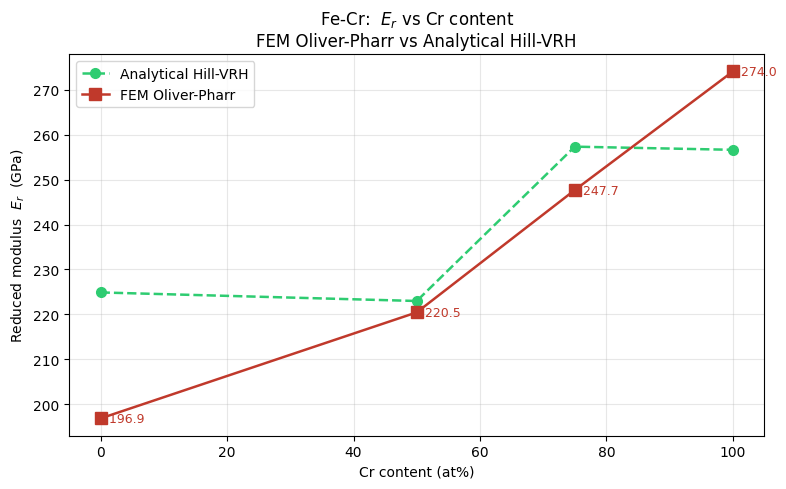

Er vs Cr% plot saved to ../fem/post/fecr_Er_vs_Cr.png


In [21]:
# ── Er vs Cr% ─────────────────────────────────────────────────────────────────
ok  = [r for r in results if r.get("status") == "ok"]
all_comps = results   # all four, for analytical line

cr_fem  = np.array([r["cr_pct"]          for r in ok])
er_fem  = np.array([r["Er_corrected_GPa"] for r in ok])
cr_all  = np.array([r["cr_pct"]          for r in all_comps])
er_anal = np.array([r["E_R_ANALYTICAL"]  for r in all_comps])
sort_all = np.argsort(cr_all)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(cr_all[sort_all], er_anal[sort_all],
        "o--", color="#2ecc71", lw=1.8, ms=7,
        label="Analytical Hill-VRH")

if len(cr_fem):
    sort_fem = np.argsort(cr_fem)
    ax.plot(cr_fem[sort_fem], er_fem[sort_fem],
            "s-", color="#c0392b", lw=1.8, ms=8,
            label="FEM Oliver-Pharr")
    for r in ok:
        ax.annotate(
            f"  {r['Er_corrected_GPa']:.1f}",
            (r["cr_pct"], r["Er_corrected_GPa"]),
            fontsize=9, va="center", color="#c0392b"
        )

# mark missing compositions as empty markers on analytical line
missing = [r for r in results if r.get("status") != "ok"]
if missing:
    ax.scatter(
        [r["cr_pct"] for r in missing],
        [r["E_R_ANALYTICAL"] for r in missing],
        s=80, facecolor="none", edgecolor="#c0392b", linewidths=1.5,
        zorder=5, label="FEM pending"
    )

ax.set_xlabel("Cr content (at%)")
ax.set_ylabel("Reduced modulus  $E_r$  (GPa)")
ax.set_title("Fe-Cr:  $E_r$ vs Cr content\nFEM Oliver-Pharr vs Analytical Hill-VRH")
ax.set_xlim(-5, 105)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(POST_DIR / "fecr_Er_vs_Cr.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Er vs Cr% plot saved to {POST_DIR / 'fecr_Er_vs_Cr.png'}")

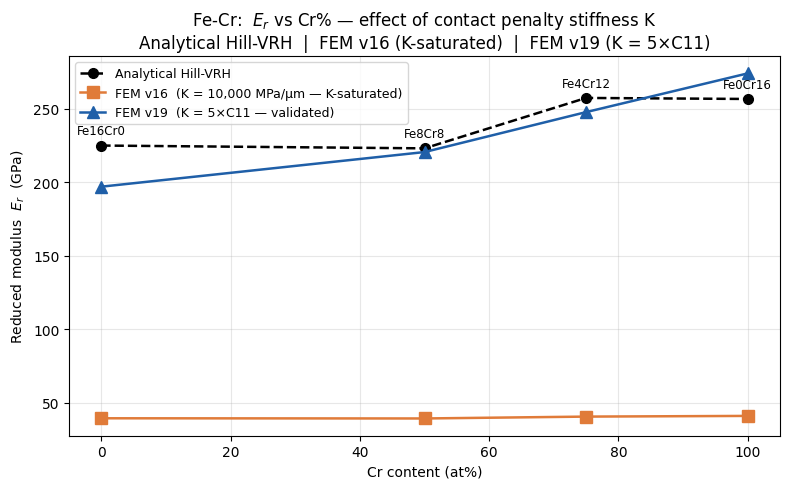

Saved to ../fem/post/fecr_Er_K_dependency.png


In [22]:
# ── K-dependency comparison: Analytical VRH vs v16 FEM vs v19 FEM ────────────
# v16 Er values from the v16 Oliver-Pharr notebook output
# v19 Er values from the results list already computed above
# Analytical VRH from COMPOSITIONS registry

v16_df = pd.read_csv("../fem/post/fecr_op_results.csv", index_col="label")

# Build aligned arrays across the four compositions
cr_axis      = []
er_analytical = []
er_v16        = []
er_v19        = []
labels        = []

for comp in COMPOSITIONS:
    tag   = comp["tag"]
    label = comp["label"]
    cr    = comp["cr_pct"]
    er_a  = comp["E_R_ANALYTICAL"]

    # v19 result — None if missing or errored
    v19_match = next((r for r in results if r["label"] == label and r.get("status") == "ok"), None)
    er_v19_val = v19_match["Er_corrected_GPa"] if v19_match else None

    # v16 result — None if composition absent from csv
    er_v16_val = None
    if label in v16_df.index and not pd.isna(v16_df.loc[label, "Er_GPa"]):
        er_v16_val = v16_df.loc[label, "Er_GPa"]

    cr_axis.append(cr)
    er_analytical.append(er_a)
    er_v16.append(er_v16_val)
    er_v19.append(er_v19_val)
    labels.append(label)

cr_axis       = np.array(cr_axis)
er_analytical = np.array(er_analytical, dtype=float)

# separate arrays for v16/v19 — only plot where data exists
cr_v16  = np.array([cr_axis[i] for i in range(len(labels)) if er_v16[i] is not None])
val_v16 = np.array([er_v16[i]  for i in range(len(labels)) if er_v16[i] is not None])
cr_v19  = np.array([cr_axis[i] for i in range(len(labels)) if er_v19[i] is not None])
val_v19 = np.array([er_v19[i]  for i in range(len(labels)) if er_v19[i] is not None])

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(cr_axis, er_analytical, "k--", lw=1.8,
        marker="o", ms=7, label="Analytical Hill-VRH")

if len(cr_v16):
    ax.plot(cr_v16, val_v16, "s-", color="#e07b39", lw=1.8,
            ms=8, label="FEM v16  (K = 10,000 MPa/µm — K-saturated)")

if len(cr_v19):
    ax.plot(cr_v19, val_v19, "^-", color="#1f5fa8", lw=1.8,
            ms=8, label="FEM v19  (K = 5×C11 — validated)")

# label each composition on the analytical line
for cr, er, lbl in zip(cr_axis, er_analytical, labels):
    ax.annotate(lbl, (cr, er), textcoords="offset points",
                xytext=(0, 8), ha="center", fontsize=8.5)

ax.set_xlabel("Cr content (at%)")
ax.set_ylabel("Reduced modulus  $E_r$  (GPa)")
ax.set_title(
    "Fe-Cr:  $E_r$ vs Cr% — effect of contact penalty stiffness K\n"
    "Analytical Hill-VRH  |  FEM v16 (K-saturated)  |  FEM v19 (K = 5×C11)"
)
ax.legend(fontsize=9)
ax.set_xlim(-5, 105)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(POST_DIR / "fecr_Er_K_dependency.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved to {POST_DIR / 'fecr_Er_K_dependency.png'}")

## Notes

- **`Er_corr`** = `Er_sample` after diamond-indenter compliance correction.
- **`Er_meas`** = raw Oliver-Pharr value before indenter correction (always lower).
- **Deviation** is relative to the analytical Hill-VRH value. ~10–15% is expected
  given the idealised conical geometry and lower-bound K.
- **Pending compositions** (open circles on Er vs Cr% plot) show the analytical
  reference; the FEM point will appear once the `.dat` file is present.
- **Fe0Cr16** is AFM-initialised (tier C); its `Er_analytical` carries higher
  ML uncertainty than the FM compositions — treat deviation with caution.
- **`E_R_ANALYTICAL` placeholders**: values for Fe8Cr8, Fe4Cr12, Fe0Cr16 must
  be replaced with the verified Hill-VRH outputs from the ML material cards notebook
  before the deviation column is meaningful.